## 1. Introduction: Hierarchical Composition

In this notebook, we merge our modular binary masks into a single **Categorical Master Mask**. 

**The Priority Hierarchy:**
1. **Class 3 (High Veg):** Highest priority (Canopy).
2. **Class 2 (Grassland):** Permeable green surfaces.
3. **Class 1 (Built-up):** Buildings and sealed surfaces.
4. **Class 0 (Background):** Any pixel not covered by the above.

**Optimization Note:** To handle 10,000 samples within Google Drive limits, we are now using:
* **JPG** for aerial images.
* **PNG** for all masks (Lossless 8-bit, ~90% smaller than TIFF).

In [ ]:
import os
import numpy as np
import geopandas as gpd
from PIL import Image # Primary library for JPG/PNG
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# --- Directory Configuration ---
BASE_OUT = "../data/modular_final"
META_DIR = f"{BASE_OUT}/metadata"

# Input Task Folders (Now containing .png files)
TASKS = ["masks_builtup", "masks_grassland", "masks_highveg"]
COMBINED_TASK = "masks_combined"

# Load anchors to get the universal file list and split info
gdf_anchors = gpd.read_file(f"{META_DIR}/building_anchors_10000.gpkg")

## 2. Defining the Hierarchical Function

By using a function, we ensure that the same logic used to create training data can be reused later to merge predictions from three separate models.

In [6]:
def compose_hierarchical_mask(built_arr, grass_arr, highveg_arr):
    """
    Combines three binary masks into one categorical mask based on priority.
    Hierarchy: HighVeg (3) > Grassland (2) > Built-up (1)
    """
    # Initialize background (Class 0)
    combined = np.zeros_like(built_arr, dtype=np.uint8)
    
    # 1. Apply Built-up (Class 1) - Lowest Priority
    combined[built_arr == 1] = 1
    
    # 2. Apply Grassland (Class 2) - Overwrites Built-up
    combined[grass_arr == 1] = 2
    
    # 3. Apply Higher Vegetation (Class 3) - Overwrites Everything
    combined[highveg_arr == 1] = 3
    
    return combined

## 3. Global Synthesis Loop

We loop through every anchor, locate the three binary TIFFs, and save the unified result.

In [7]:
# Process all three splits
for split in ['train', 'val', 'test']:
    os.makedirs(f"{BASE_OUT}/{split}/{COMBINED_TASK}", exist_ok=True)

print(f"Synthesizing combined masks for {len(gdf_anchors)} samples...")

for idx, row in tqdm(gdf_anchors.iterrows(), total=len(gdf_anchors)):
    uid, split = row['unique_id'], row['split']
    
    # Paths to the PNG binary masks
    path_built = f"{BASE_OUT}/{split}/masks_builtup/{uid}_mask.png"
    path_grass = f"{BASE_OUT}/{split}/masks_grassland/{uid}_mask.png"
    path_highveg = f"{BASE_OUT}/{split}/masks_highveg/{uid}_mask.png"
    out_path = f"{BASE_OUT}/{split}/{COMBINED_TASK}/{uid}_mask.png"
    
    if os.path.exists(out_path): continue
    
    try:
        # Open as PIL images and convert to numpy arrays
        m_built = np.array(Image.open(path_built))
        m_grass = np.array(Image.open(path_grass))
        m_highveg = np.array(Image.open(path_highveg))
        
        # Combine using priority logic
        final_mask = compose_hierarchical_mask(m_built, m_grass, m_highveg)
        
        # Save as 8-bit PNG
        Image.fromarray(final_mask).save(out_path)
                
    except FileNotFoundError:
        # Skips if a specific mask wasn't generated for this anchor
        continue

print("✅ All hierarchical masks synthesized and saved as PNG.")

Synthesizing combined masks for 10000 samples...


  0%|          | 0/10000 [00:00<?, ?it/s]

✅ All hierarchical masks synthesized and saved as PNG.


## 4. Final Sanity Check

We visualize a random sample to ensure the colors represent the correct hierarchy.

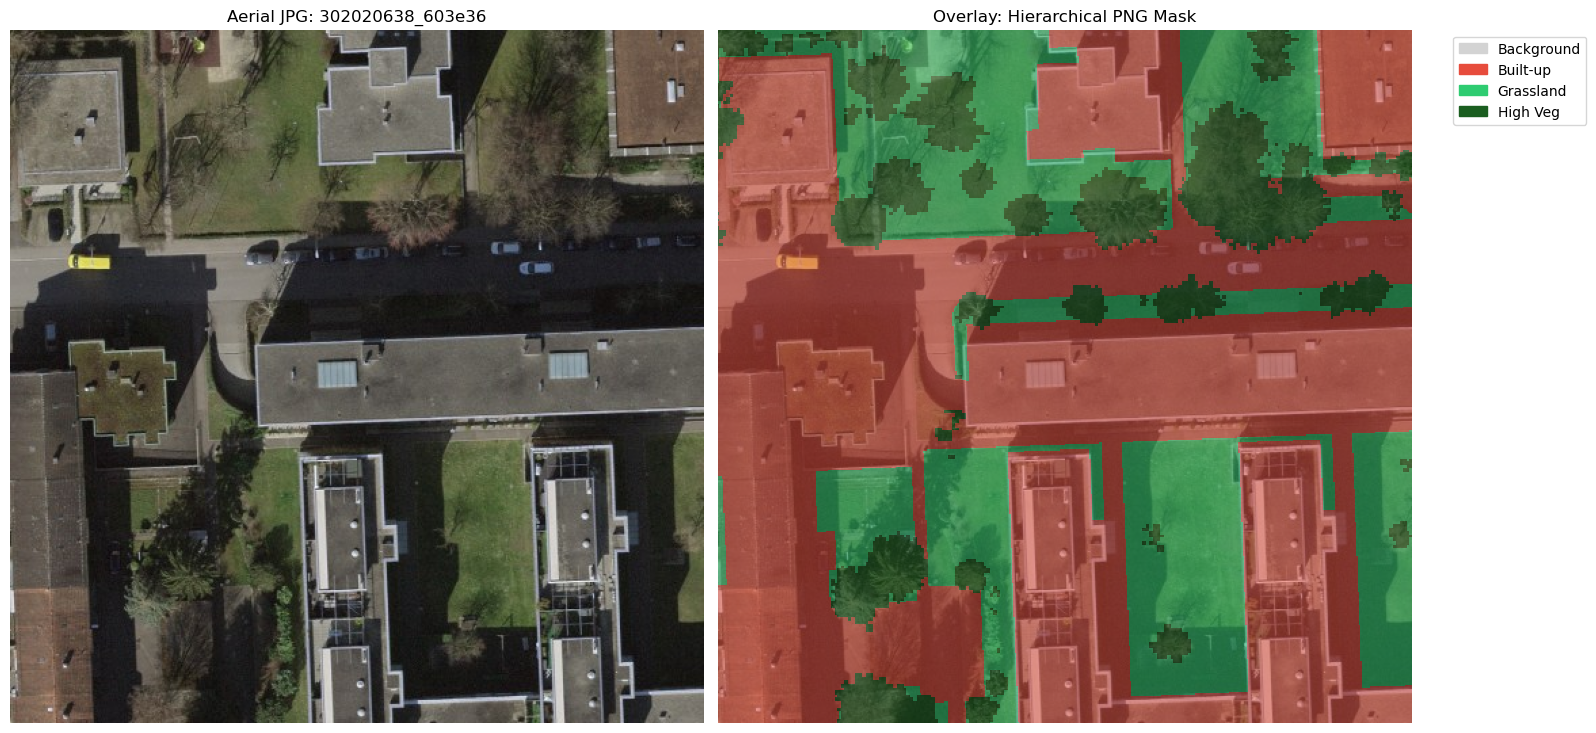

Sample Split: val
Unique Values in Mask: [1 2 3]


In [8]:
# Sample a random anchor
sample = gdf_anchors.sample(1).iloc[0]
uid, split = sample['unique_id'], sample['split']

# Load the new formats
img_path = f"{BASE_OUT}/{split}/images/{uid}_swissimage.jpg"
mask_path = f"{BASE_OUT}/{split}/{COMBINED_TASK}/{uid}_mask.png"

# Load with PIL
img_img = Image.open(img_path).convert("RGB")
mask_img = Image.open(mask_path)

img_arr = np.array(img_img)
mask_arr = np.array(mask_img)

# Custom colormap: 0:Grey, 1:Red, 2:LightGreen, 3:DarkGreen
custom_cmap = ListedColormap(['#d3d3d3', '#e74c3c', '#2ecc71', '#1b5e20'])

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(img_arr)
ax[0].set_title(f"Aerial JPG: {uid}")
ax[0].axis('off')

ax[1].imshow(img_arr) # Background aerial
im = ax[1].imshow(mask_arr, cmap=custom_cmap, vmin=0, vmax=3, alpha=0.5, interpolation='nearest')
ax[1].set_title("Overlay: Hierarchical PNG Mask")
ax[1].axis('off')

# Legend
labels = {0: 'Background', 1: 'Built-up', 2: 'Grassland', 3: 'High Veg'}
patches = [mpatches.Patch(color=custom_cmap(i), label=labels[i]) for i in range(4)]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(f"Sample Split: {split}")
print(f"Unique Values in Mask: {np.unique(mask_arr)}")